In [1]:
import qgutils as qg
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from diagnostics_pkg import operators_layered as ol
import qgutils as qg
import scipy
import gsw
from scipy.interpolate import RegularGridInterpolator
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from legendkit import legend
from legendkit.layout import vstack, hstack

In [2]:
# calculate mean temperature and salinity fields from LEVITUS dataset. (not included in this repository, consult paper on how to access)

# open temperature data
savedir = "../../../../SW/project_simple_param_space/LEVITUS/"
filename = "otemp.hr.annltm.nc"
ds = xr.open_dataset(savedir + filename)
T_fine = ds["otemp"][0,:,:,:]

# open salinity data
filename = "salt.hr.annltm.nc"
ds = xr.open_dataset(savedir + filename)
S_fine = ds["salt"][0,:,:,:]

/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/xarray/coding/times.py:167: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)
/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/xarray/coding/times.py:832: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/lennard/miniconda3/envs/DA/lib/python3.12/site-packages/xarray/core/indexing.py:560: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.dateti

In [3]:
# calculate maps

S = S_fine.coarsen(lat = 1, lon = 1).mean()
T = T_fine.coarsen(lat = 1, lon = 1).mean()

z = S.level.values
P = 1e3*9.81*z/1e4 

CT = gsw.CT_from_t(S, T, P[:,None,None])
drho = gsw.density.sigma0(S, CT)

In [4]:
# Calculate example stratification over Gulf Stream region, defined by the polygon spanned by these four points.

lon_p1 = -79.9 + 360
lat_p1 = 32

lon_p2 = -80 + 360
lat_p2 = 26

lon_p3 = -65 + 360
lat_p3 = 36

lon_p4 = -70 + 360
lat_p4 = 42


def custom_condition3(data_array, lat_p1, lon_p1, lat_p2, lon_p2):
    return (data_array.lat - lat_p1)/(lat_p2 - lat_p1) > (data_array.lon - lon_p1)/(lon_p2 - lon_p1)

da = S_fine
selected_da = da.where(custom_condition3(da, lat_p1, lon_p1, lat_p2, lon_p2))
selected_da = selected_da.where(custom_condition3(da, lat_p4, lon_p4, lat_p3, lon_p3))
selected_da = selected_da.where(custom_condition3(da, lat_p2, lon_p2, lat_p3, lon_p3))
selected_da = selected_da.where(custom_condition3(da, lat_p4, lon_p4, lat_p1, lon_p1))
S_gulf = selected_da

da = T_fine
selected_da = da.where(custom_condition3(da, lat_p1, lon_p1, lat_p2, lon_p2))
selected_da = selected_da.where(custom_condition3(da, lat_p4, lon_p4, lat_p3, lon_p3))
selected_da = selected_da.where(custom_condition3(da, lat_p2, lon_p2, lat_p3, lon_p3))
selected_da = selected_da.where(custom_condition3(da, lat_p4, lon_p4, lat_p1, lon_p1))
T_gulf = selected_da

z = S.level.values
P = 1e3*9.81*z/1e4

CT = gsw.CT_from_t(S_gulf, T_gulf, P[:,None,None])
drho_gulf = gsw.density.sigma0(S_gulf, CT)

drho_gulf_m = np.nanmean(drho_gulf, axis = (-2, -1))
z = -drho_gulf.level

/tmp/ipykernel_13702/168410476.py:39: RuntimeWarning: Mean of empty slice
  drho_gulf_m = np.nanmean(drho_gulf, axis = (-2, -1))


In [5]:
# Basilisk configuration

rho0 = 1000
basilisk_strat =  np.array([ 2.13/rho0, 1.72/rho0, 1.41/rho0, 1.01/rho0, 0. ])
basilisk_strat = basilisk_strat[::-1] - basilisk_strat[0]
basilisk_layer_depths = [250, 250, 250, 250, 0]
basilisk_depth = np.cumsum(basilisk_layer_depths[::-1]) + 125
basilisk_depth[-1] = 2500
basilisk_depth = -basilisk_depth

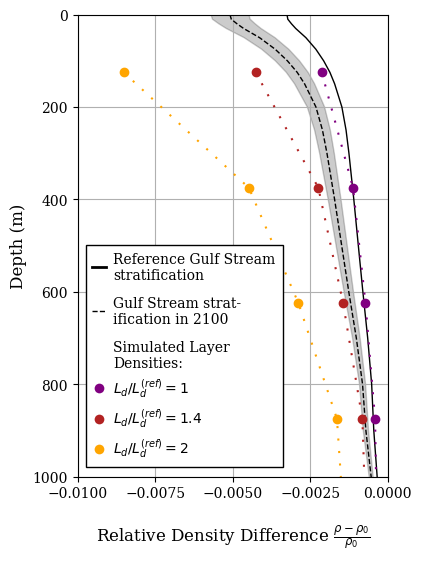

In [6]:
plt.rcParams['font.family'] = 'serif'

fig = plt.figure(figsize = (4,6))

rho_ref = drho_gulf_m[-2]

axes = fig.subplots(1,1)
y_lim = 1000
xlim1 = 24 - rho_ref
xlim2 = 28 - rho_ref

depth = -np.array([125, 375, 625, 875, 3000])
xlim1 = -0.01
xlim2 = -0
rho_ref2 = rho_ref+1000

ax = axes
# plot reference gulf stream stratification from Levitus
ax.plot((drho_gulf_m  - drho_gulf_m[-2])/rho_ref2, z, color = "k", linestyle = "-", label = 'Reference Gulf Stream stratification (Levitus, 1984)', linewidth = 1)

# combine with extrapolation of stratification trend from Todd (2023)
ax.plot((drho_gulf_m  - drho_gulf_m[-2] - (drho_gulf_m - drho_gulf_m[-2])/(drho_gulf_m[0] - drho_gulf_m[-2])*0.015*126)/rho_ref2, z, linestyle = "--", label = 'Gulf Stream stratification\nin 100 years (Todd and Ren, 2023)', linewidth = 1, color = "k")

# add error bars
axes.fill_betweenx(z, (drho_gulf_m  - drho_gulf_m[-2] - (drho_gulf_m - drho_gulf_m[-2])/(drho_gulf_m[0] - drho_gulf_m[-2])*0.01*126)/rho_ref2, (drho_gulf_m  - drho_gulf_m[-2] - (drho_gulf_m - drho_gulf_m[-2])/(drho_gulf_m[0] - drho_gulf_m[-2])*0.02*126)/rho_ref2, alpha = 0.2, color = "k")

# add simulated stratification profiles
ax.plot(basilisk_strat, basilisk_depth, marker = "o", linestyle =  (0, (1, 5)), color = "purple", label=r'$L_d/L_d^{ref} = 1$')
ax.plot(2*basilisk_strat, basilisk_depth, marker = "o", linestyle = (0, (1, 5)), color = "firebrick", label=r'$L_d/L_d^{ref} = 1.4$')
ax.plot(4*basilisk_strat, basilisk_depth, marker = "o", linestyle = (0, (1, 5)), color = "orange", label=r'$L_d/L_d^{ref} = 2$')

ax.set_ylim([-y_lim, 0])
ax.set_xlim([xlim1, xlim2])
ax.set_xticks(np.linspace(xlim1, xlim2, 5))
ax.set_yticks(np.linspace(-y_lim, 0, 6), [str(i) for i in range(0,1001,200)][::-1])
ax.grid()
ax.set_ylabel("Depth (m)", size = 12)

# create fancy legend
legend1 = legend(legend_items=[
    ('line', 'Reference Gulf Stream\nstratification', {'color': 'k', 'linewidth': '2'})
], handlelength = 1, alignment="center", loc="center", borderpad = -1.5)

legend2 = legend(legend_items=[
    ('line', 'Gulf Stream strat-\nification in 2100', {'color': 'k', 'linewidth': '1', 'linestyle':'dashed'}),
], handlelength = 1, alignment="center", loc="center", borderpad = -1.5)

legend3 = legend(legend_items=[('', 'Simulated Layer\nDensities:'),
    ('circle', r'$L_d/L_d^{(ref)} = 1$', {'facecolor': 'purple', 'edgecolor': 'None','markersize':'7'}),
    ('circle', r'$L_d/L_d^{(ref)} = 1.4$', {'facecolor': 'firebrick', 'edgecolor': 'None','markersize':'7'}),
    ('circle', r'$L_d/L_d^{(ref)} = 2$', {'facecolor': 'orange', 'edgecolor': 'None','markersize':'7'}),
], handlelength = 1, alignment="center", loc="center", borderpad = -1.5)

legends = vstack([legend1, legend2,legend3], spacing=40, frameon=True)
divider = make_axes_locatable(axes)
lax = axes.inset_axes((0.025, 0.02,0.05, 0.5))

lax.set_axis_off()
lax.add_artist(legends)  

ax.set_xlabel(r"Relative Density Difference $\frac{\rho - \rho_0}{\rho_0}$", position = (-2,0), size = 12)
ax.xaxis.set_label_coords(0.5, -0.1)
plt.savefig('strat_comp.png', dpi = 200, bbox_inches='tight', format = 'png')